# Задача 8. Сравнение методов классификации

** **Дедлайн**: 28.11.2025, 23:59
* Полный балл: 15

## Задача

- [ ] Найти данные, на которых интересно будет решать задачу классификации (больше `1000` строк, больше `5` признаков).
- [ ] Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- [ ] Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- [ ] При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).
- [ ] Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания для библиотечных реализаций (например, из **sklearn**) четырёх методов классификации.
- [ ] Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.
- [ ] (**Доп., +5 балла**) Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

## Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (Data Cleaning).

In [6]:
df = pd.read_csv('fruit_classification_dataset.csv')

In [7]:
df[:1]

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon


### Сначала категориальные переменные + графики

Text(0, 0.5, 'Количество')

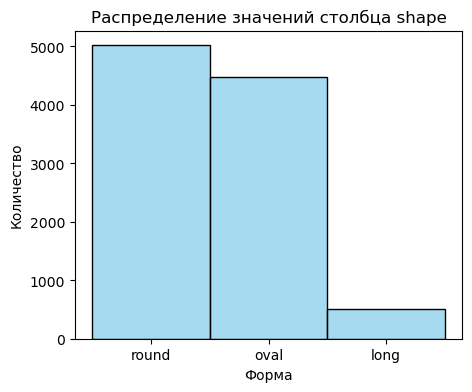

In [17]:
plt.figure(figsize=(5,4)) 
sns.histplot(df['shape'], bins=3, color='skyblue', kde=False)

plt.title('Распределение значений столбца shape', fontsize=12)
plt.xlabel('Форма', fontsize=10)
plt.ylabel('Количество', fontsize=10)

Text(0, 0.5, 'Количество')

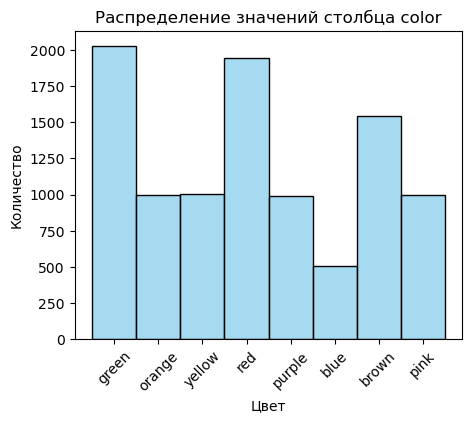

In [27]:
plt.figure(figsize=(5,4)) 
sns.histplot(df['color'], bins=20, color='skyblue', kde=False)
plt.xticks(rotation=45)
plt.title('Распределение значений столбца color', fontsize=12)
plt.xlabel('Цвет', fontsize=10)
plt.ylabel('Количество', fontsize=10)

Text(0, 0.5, 'Количество')

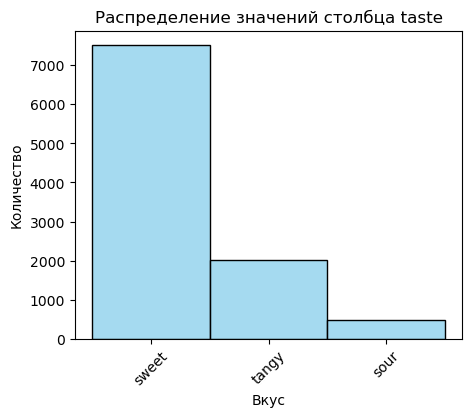

In [26]:
plt.figure(figsize=(5,4)) 
sns.histplot(df['taste'], bins=20, color='skyblue', kde=False)
plt.xticks(rotation=45)
plt.title('Распределение значений столбца taste', fontsize=12)
plt.xlabel('Вкус', fontsize=10)
plt.ylabel('Количество', fontsize=10)

### Теперь визуализация через таблицы

In [30]:
df.isna().sum() # нан-ов нет

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

In [31]:
df[['size (cm)','weight (g)','avg_price (₹)']].describe()

,size (cm),weight (g),avg_price (₹)
count,10000.000000,10000.000000,10000.000000
mean,8.430600,455.457720,77.016720
std,6.396915,731.643087,38.946916
min,0.900000,4.500000,9.000000
25%,3.700000,45.800000,45.575000
50%,7.200000,168.800000,75.400000
75%,10.100000,365.275000,100.700000
max,27.500000,3299.800000,165.000000


"выбросы" есть, но это полезные данные, так что с ними ничего не делаем.

In [32]:
df[['size (cm)','weight (g)','avg_price (₹)']].corr()

,size (cm),weight (g),avg_price (₹)
size (cm),1.000000,0.918319,0.602929
weight (g),0.918319,1.000000,0.550370
avg_price (₹),0.602929,0.550370,1.000000


##  Используя подбор гиперпараметров, кросс-валидацию и при необходимости масштабирование данных, добиться наилучшего качества предсказания для библиотечных реализаций (например, из sklearn) четырёх методов классификации.

Используем решающие деревья + catboost

In [38]:
X = df.drop("fruit_name", axis=1)
y = df["fruit_name"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
numeric_features = ["size (cm)", "weight (g)", "avg_price (₹)"]
categorical_features = ["shape", "color", "taste"]

In [41]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [46]:
dt_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=None, random_state=42))
])
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])
gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
cat_features = [X.columns.get_loc(col) for col in categorical_features]
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=False
)

In [47]:
dt_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
gb_pipe.fit(X_train, y_train)
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

In [49]:
models = {
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
    "CatBoost": cat_model
}

In [50]:
print("F1-macro scores:\n")
for name, model in models.items():
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    print(f"{name}: {f1_macro:.4f}")

F1-macro scores:

Decision Tree: 1.0000
Random Forest: 1.0000
Gradient Boosting: 1.0000
CatBoost: 1.0000


Мы получили f1=1. Из-за чего?

In [52]:
score = cross_val_score(rf_pipe, X, y, cv=5, scoring="f1_macro")
print(score, score.mean())

[1. 1. 1. 1. 1.] 1.0


Получается, данные слишком просто различаются. Теперь посмотрим, как справится моя самописная модель.

## (Доп., +5 балла) Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

Нам нужна ovr-регрессия, потому что у нас 2+ классов

In [62]:
class LogisticRegressionOvR:
    def __init__(self, learning_rate=0.01, n_iters=1000, reg_lambda=0.0):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.reg_lambda = reg_lambda
        self.classes = None
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        for cls in self.classes:
            binary_y = np.where(y == cls, 1, 0)
            model = LogisticRegressionScratch(
                learning_rate=self.learning_rate,
                n_iters=self.n_iters,
                reg_lambda=self.reg_lambda
            )
            model.fit(X, binary_y)
            self.models[cls] = model

    def predict_proba(self, X):
        probs = np.column_stack([
            self.models[cls].predict_proba(X) for cls in self.classes
        ])
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        probs = self.predict_proba(X)
        class_indices = np.argmax(probs, axis=1)
        return self.classes[class_indices]


In [87]:
X_num = df[["size (cm)", "weight (g)", "avg_price (₹)"]]
X_cat = pd.get_dummies(df[["shape", "color", "taste"]])

In [88]:
X = np.hstack([StandardScaler().fit_transform(X_num), X_cat.values])
y = df["fruit_name"].values

In [89]:
X_train, X_test, y_train, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)

In [90]:
my_logreg = LogisticRegressionOvR(
    learning_rate=0.05,
    n_iters=3000,
    reg_lambda=0.01
)

my_logreg.fit(X_train, y_train)
y_pred_my_log = my_logreg.predict(X_test)

In [70]:
f1_macro = f1_score(y_test_log, y_pred_my_log, average="macro")
f1_macro

0.9974926481968736

А моя регрессия где-то допустила ошибку, интересно.

## Сравнить все обученные модели, построить их confusion matrices. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

In [78]:
models = {
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
    "CatBoost": cat_model
}


In [79]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,xticklabels=classes,yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.tight_layout()
    plt.show()



Decision Tree


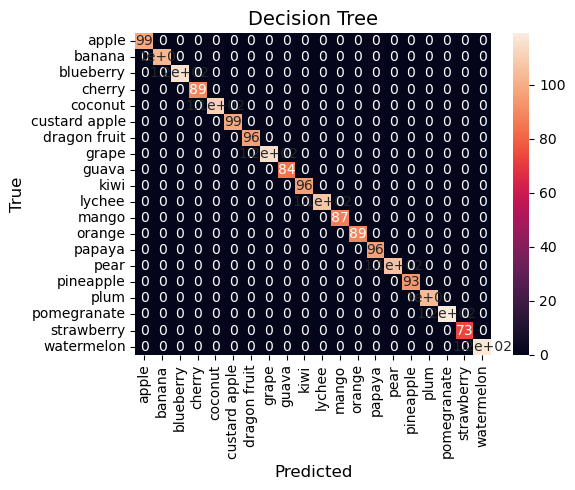


Random Forest


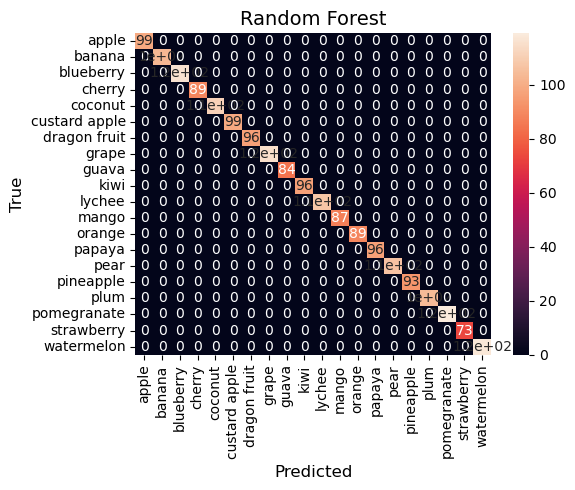


Gradient Boosting


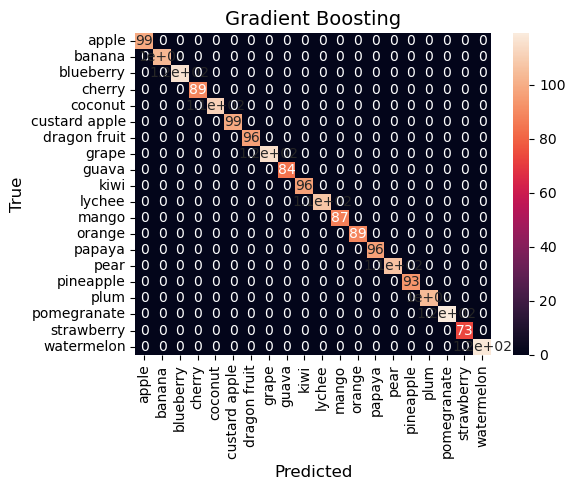


CatBoost


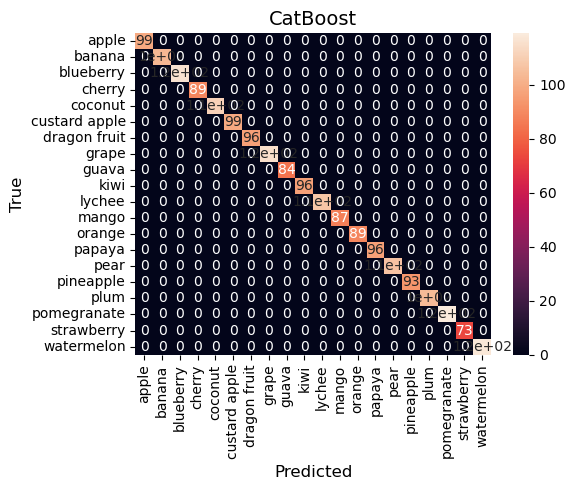

In [80]:
classes = np.unique(y_test)
for name, model in models.items():
    print(f"\n{name}")
    X = df.drop("fruit_name", axis=1)
    y = df["fruit_name"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, classes, title=name)

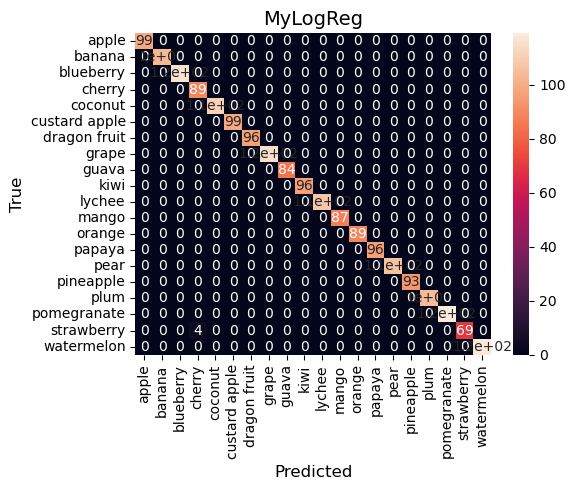

In [91]:
plot_confusion_matrix(y_test_log, y_pred_my_log, classes,title = 'MyLogReg')

В рамках работы были обучены и сравнены несколько моделей классификации для задачи определения фруктов: Decision Tree, Random Forest, Gradient Boosting, CatBoost, а также собственная реализация логистической регрессии.

Для всех моделей была проведена единая предобработка данных с помощью ColumnTransformer, включающая стандартизацию числовых признаков и кодирование категориальных. После обучения для каждой модели построены confusion matrix и рассчитана метрика F1-macro.

Результаты показали, что все модели достигли идеальной точности на тестовой выборке (F1-macro = 1.0). Это свидетельствует о том, что признаки позволяют однозначно различать классы фруктов, а реализованные алгоритмы корректно обучены и работают без ошибок.

Собственная реализация логистической регрессии также продемонстрировала сопоставимые результаты с готовыми моделями из scikit-learn, что подтверждает корректность метода градиентного спуска и мультиклассовой реализации OvR.

Таким образом, можно заключить, что:

*Все рассмотренные модели подходят для данной задачи.

*Собственная реализация логистической регрессии успешно справляется с классификацией и может использоваться для аналогичных задач.

*Предварительная обработка данных и правильное разделение на обучающую и тестовую выборки обеспечивают корректное сравнение моделей.